# rfscorer Basic Usage

This notebook demonstrates the basic workflow of `rfscorer`:

1. Load an interaction log and rename columns
2. Split users into train / test sets
3. Fit the scorer to estimate empirical revisit probabilities
4. Visualize the empirical probability surface
5. Optimize probabilities under RF monotonicity constraints (mono)
6. Optimize probabilities under MCC constraints (mcc)
7. Generate recommendation scores with `transform()`
8. Evaluate recommendation quality with `evaluate()`

In [1]:
import pandas as pd

from rfscorer import RecencyFrequencyScorer

## 1. Load Data

Load the interaction log from CSV and rename columns to match
the scorer's default names (`user`, `item`, `datetime`).
Each row represents one user–item interaction.
The same pair may appear multiple times (repeat visits).

> `access_log.csv` is sourced from [ohmsha/PyOptBook](https://github.com/ohmsha/PyOptBook/tree/main/7.recommendation) (MIT License).

In [2]:
url = "https://raw.githubusercontent.com/ohmsha/PyOptBook/main/7.recommendation/access_log.csv"
df = pd.read_csv(url)
df.columns = ["user", "item", "datetime"]

print(f"{len(df):,} rows  |  {df.user.nunique():,} users  |  {df.item.nunique():,} items")
df.head()

325,908 rows  |  31,443 users  |  87,611 items


,user,item,datetime
0,4,205587,2015-07-04
1,4,748683,2015-07-04
2,4,790055,2015-07-04
3,4,790055,2015-07-04
4,4,764638,2015-07-04


## 2. Train / Test Split

Split users into a training set (80 %) and a test set (20 %) using a hash-based partition.

In [3]:
df_train = df[df.user.map(lambda x: hash(x) % 10 < 8)]
df_test = df[df.user.map(lambda x: hash(x) % 10 >= 8)]
print(f"Train: {len(df_train):,} rows ({df_train.user.nunique():,} users)")
print(f"Test:  {len(df_test):,} rows ({df_test.user.nunique():,} users)")

Train: 264,272 rows (25,316 users)
Test:  61,636 rows (6,127 users)


## 3. Fit — Empirical Revisit Probabilities

Split the training log into an observation window (`<= target_date`) and an
evaluation window (`> target_date`), then pass both to `fit()`.
Recency and frequency are computed from the observation window;
the evaluation window provides ground-truth revisit labels.

In [4]:
scorer = RecencyFrequencyScorer()

target_date = "2015-07-07"
df_train_obs = df_train[df_train.datetime <= target_date]
df_train_eval = df_train[df_train.datetime > target_date]
scorer.fit(df_train_obs, df_train_eval)
scorer.show()

=== profiling ===
record_num: 264272
record_num_obs: 232157
record_num_eval: 32115
observation: 2015-07-01 00:00:00 -> 2015-07-07 00:00:00
evaluation: 2015-07-08 00:00:00 -> 2015-07-08 00:00:00
recency_limit: 7
frequency_limit: 8
target_record_num: 165833 -> 165134
total_cv: 1783 -> 1712
empirical_probability_table_:
frequency      1      2      3      4      5      6      7      8
recency                                                          
1          0.014  0.041  0.081  0.052  0.132  0.134  0.163  0.157
2          0.006  0.023  0.027  0.048  0.072  0.083  0.049  0.122
3          0.006  0.023  0.038  0.064  0.044  0.052  0.041  0.068
4          0.005  0.015  0.023  0.042  0.042  0.027  0.011  0.019
5          0.004  0.017  0.025  0.015  0.027  0.030  0.039  0.026
6          0.004  0.011  0.029  0.023  0.005  0.021  0.031  0.000
7          0.005  0.009  0.012  0.025  0.012  0.027  0.000  0.000


## 4. Visualize — Empirical Probability Surface

Plot the empirical revisit probabilities as a 3-D wireframe.
Recency increases along the x-axis (1 = most recent);
frequency increases along the y-axis.
This surface shows the raw, unsmoothed probabilities before optimization.

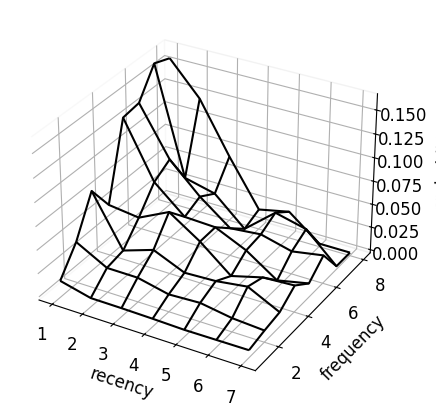

In [5]:
fig_emp = scorer.plot_probability_surface(kind="emp")

## 5. Optimize — Monotonicity Constraints (mono)

`kind='mono'` enforces that probabilities are monotone decreasing in recency
and monotone increasing in frequency.

=== show solve info ===
kind: mono
eps: 0.0
status: optimal
objective_value: 0.7913
elapsed_time: 0.04[s]
num_variables: 56
num_constraints: 209


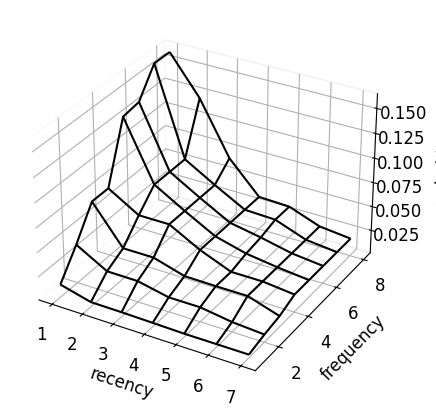

In [6]:
scorer.optimize(kind="mono")
fig_mono = scorer.plot_probability_surface(kind="mono")

## 6. Optimize — MCC Constraints (mcc)

`kind='mcc'` additionally imposes convexity in recency and concavity in frequency
(diminishing marginal returns), yielding a smoother surface.

=== show solve info ===
kind: mcc
eps: 0.0
status: optimal
objective_value: 1.8428
elapsed_time: 0.07[s]
num_variables: 56
num_constraints: 291


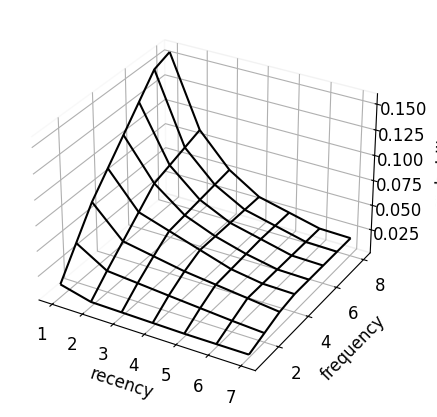

In [7]:
scorer.optimize(kind="mcc")
fig_mcc = scorer.plot_probability_surface(kind="mcc")

## 7. Transform — Generate Recommendation Scores

Filter the test log to the observation window (`<= target_date`) before scoring.
`transform()` scores each user–item pair, computing recency and frequency relative to `target_date`.
Within each user, rows are sorted by `probability` descending;
`order` represents the recommendation rank (1 = top recommendation).

In [8]:
df_test_obs = df_test[df_test.datetime <= target_date]
df_test_eval = df_test[df_test.datetime > target_date]

df_rec = scorer.transform(df_test_obs, target_date, kind="mcc")
df_rec.head(10)

,user,item,recency,frequency,probability,order
9190,100099,311656,4,1,0.005009,1
9191,100099,411961,4,1,0.005009,2
9192,100129,353070,5,4,0.024996,1
9196,100138,591186,6,4,0.020067,1
9193,100138,852831,6,3,0.020067,2
9194,100138,1111746,6,2,0.012395,3
9197,100138,81286,2,1,0.006109,4
9198,100138,587992,2,1,0.006109,5
9199,100138,686685,2,1,0.006109,6
9200,100138,328892,2,1,0.006109,7


## 8. Evaluate — Recommendation Quality

`df_test_eval` contains interactions in `df_test` after `target_date` (ground-truth revisits).
`evaluate()` reports precision, recall, and F1 at each recommendation rank cutoff.

In [9]:
scorer.evaluate(df_rec, df_test_eval, order=5)

,order,n_recommended,n_hit,precision,recall,f1,recall_norm,f1_norm
0,1,5547,104,0.018749,0.018009,0.018371,0.280323,0.035147
1,2,10583,166,0.015686,0.028745,0.020296,0.447439,0.030309
2,3,14336,209,0.014579,0.036190,0.020785,0.563342,0.028422
3,4,17322,240,0.013855,0.041558,0.020782,0.646900,0.027129
4,5,19742,261,0.013221,0.045195,0.020457,0.703504,0.025953
5,195,38828,371,0.009555,0.064242,0.016636,1.000000,0.018929
